In [1]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(gridExtra)
quiet_library(grid)
quiet_library(fgsea)
quiet_library(stringr)
quiet_library(ggthemes)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 1, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}
'%ni%' <- Negate('%in%')

Warning message:
“package ‘RcppML’ was built under R version 4.3.3”


In [2]:
wd <- "/home/workspace/IFN/"
setwd(wd)
fig_dir <- file.path(wd, "Figures")

In [3]:
isgs <- fread(file.path(wd, "DEGs", "IFNa_IFNg_all_bulk_subtype_DEGs.csv"))$ifn_genes

In [ ]:
set.seed(123)

### Get L1 cell type frequencies from batch 7

In [4]:
so <- readRDS(file.path(wd, "Batch7", "batch7_so.rds"))
so_meta <- so@meta.data

In [8]:
# get PBMC L1 cell type frequencies
so_meta <- so_meta %>% filter(celltype.l1 %ni% c("DC", "other"))
so_meta$celltype.l1 <- recode(so_meta$celltype.l1,
                              "CD4 T" = "Tcell",
                              "CD8 T" = "Tcell",
                              "other T" = "Tcell",
                              "B" = "Bcell",
                              "Mono" = "Monocyte")

freqs <- table(so_meta$celltype.l1)/sum(table(so_meta$celltype.l1))

In [16]:
freqs


     Bcell   Monocyte         NK      Tcell 
0.09140150 0.15445241 0.09553131 0.65861478 

### Approximate PBMC from enriched populations and calculate N=1 DEGs 

In [12]:
stims <- c("IFNa", "IFNb", "IFNg", "IFN-L1")
donors <- c("3955BW", "3283BW", "2616BW", "6811BW", "3491BW")
celltypes <- c("Monocyte", "NK", "Tcell", "Bcell")

In [ ]:
# create named list of cell type objects
so_celltypes <- lapply(celltypes, function(c){
        readRDS(file.path(wd, "seurat_objects", "celltype_objects", glue("{c}_so_cleaned_v2.rds"))) %>% 
            subset(DonorID == d)
    })
names(so_celltypes) <- celltypes

In [ ]:
# DEG pipeline across donors, stims and cell types
for (d in donors){
    print(d)
    so_celltypes <- lapply(celltypes, function(c){
        so <- readRDS(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned", glue("{c}_so_cleaned_v1.rds"))) %>% 
            subset(DonorID == d)
        so$CDR <- scale(so$nFeature_RNA)
        so
    })
    names(so_celltypes) <- celltypes
     
        for (i in stims){    
            
            # cell sampling across 20 iterations
            lapply(1:20, function(n){
                sos <- lapply(celltypes, function(c){
        
                    so <- so_celltypes[[c]]
                    cellN_unstim <- so@meta.data %>% filter(Stim == "none") %>% rownames() %>% length()
                    
                    # set sampling number at PBMC freq times 10000 (average number of cells per sample)
                    sampleN <- freqs[[c]]*10000

                    # sampling
                    cells_sample <- c(so@meta.data %>% filter(Stim == i) %>% rownames() %>% 
                                          sample(round(freqs[[c]]*10000)),
                                      so@meta.data %>% filter(Stim == "none") %>% rownames() %>% 
                                          sample(round(freqs[[c]]*10000)))
                                        } 
                    subset(so, cells = cells_sample)
                })
                so_comb <- Reduce(merge, sos)
                
                # run MAST DEG normal
                degs <- FindMarkers(so_comb, ident.1 = i, ident.2 = "none", features = isgs, latent.vars = "CDR",
                                    group.by = "Stim", test.use = "MAST", logfc.threshold = 0, min.pct = 0.01)
                degs$gene <- rownames(degs)
                degs$stim <- i
                degs <- degs[,c("gene", "stim", colnames(degs)[1:5])]
                degs %>% 
                    arrange(-abs(avg_log2FC)) %>%
                    fwrite(file.path(wd, "DEGs", "MAST_N1_downsample", "PBMC",
                                     glue("{d}_{i}_DEGs_MAST_iteration{n}.csv")))
                
                })

    }
}


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!



In [126]:
### As with initial batches, create consensus DEG lists across cell sampling iterations
lapply(stims, function(i){  
            degs_all_donors <- map_dfr(donors, function(d){   

                            degs_all_iterations <- map_dfr(1:20, function(n){          
                                # run MAST DEG
                                degs <- fread(file.path(wd, "DEGs", "MAST_N1_downsample", "PBMC", 
                                                     glue("{d}_{i}_DEGs_MAST_iteration{n}.csv"))) 
                                degs$iteration <- n
                                degs
                                
                            })

                            degs_all_iterations_comb <- degs_all_iterations %>%
                                  group_by(gene) %>%
                                  mutate(iteration_median_log2FC = median(avg_log2FC)) %>% 
                                  mutate(iteration_median_pval = median(p_val_adj)) %>% 
                                    select(gene, stim, iteration_median_log2FC, iteration_median_pval) %>%
                                    unique() 
                        
                            degs_all_iterations_comb %>% 
                                    fwrite(file.path(wd, "DEGs", "MAST_N1_downsample", "PBMC",
                                                  glue("{d}_{i}_DEGs_MAST_consensus.csv"))) 


                            degs_all_iterations_comb$donor <- d
                            degs_all_iterations_comb

                        
                    })
    
                    degs_consensus <- degs_all_donors %>% 
                        group_by(gene) %>% 
                        summarise(median_log2FC = median(iteration_median_log2FC),
                                 median_pval = median(iteration_median_pval)
                                 ) %>%
                        unique() %>% 
                        arrange(-abs(median_log2FC))

                    degs_consensus %>% fwrite(file.path(wd, "DEGs", "MAST_N1_downsample", "PBMC", 
                                                        glue("Consensus_{i}_DEGs_MAST.csv")))

                
})


[[1]]
NULL

[[2]]
NULL

### Compare IFNa logFC of real vs in-silico PBMC

In [10]:
real_degs <- fread(file.path(wd, "DEGs", "MAST_N1_downsample", "Bulk_All", "PBMC_actual", "PBMC_MAST_IFNa_degs.csv") )
theoretical_degs <- fread(file.path(wd, "DEGs", "MAST_N1_downsample", "PBMC", "Consensus_IFNa_DEGs_MAST.csv"))

In [11]:
degs_df <- real_degs %>% left_join(theoretical_degs)

Joining with `by = join_by(gene)`


In [12]:
genes_label <- degs_df %>% slice_max(avg_log2FC, n = 5) %>% pull(gene)
degs_df$label <- ifelse(degs_df$gene %in% genes_label, degs_df$gene, NA)

degs_df <- degs_df %>%
    mutate(
      color = case_when(
        avg_log2FC > 0 & median_log2FC > 0 ~ "red",  
        avg_log2FC < 0 & median_log2FC < 0 ~ "blue",
        TRUE ~ "gray"                     
      )
    )

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1117 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


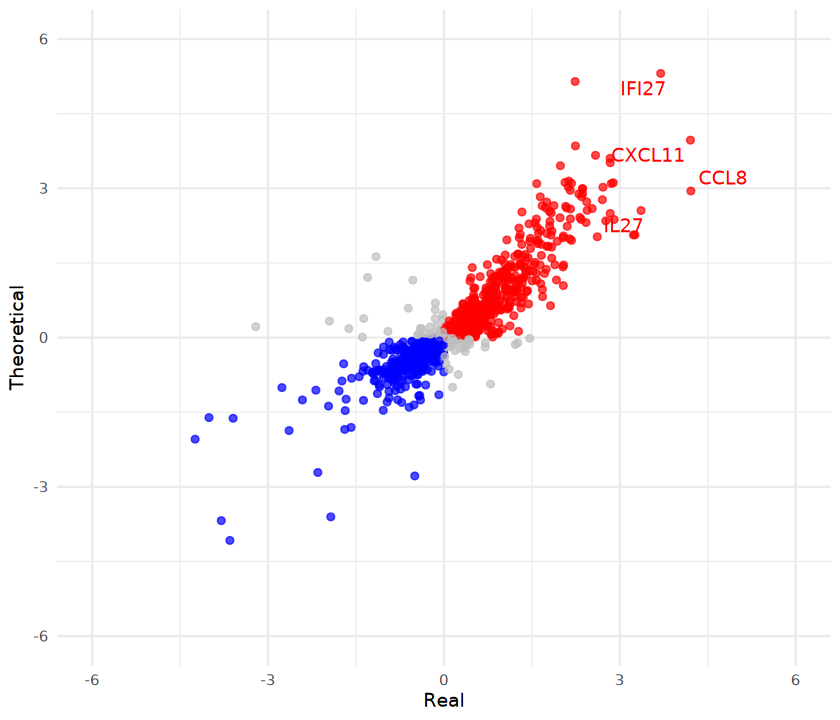

In [15]:
fig.size(6,7)
ggplot(degs_df, aes(x=avg_log2FC, y=median_log2FC, label = label, color = color)) + 
  geom_point(alpha = 0.7) + 
    xlim(c(-6,6)) + 
    ylim(c(-6,6)) + 
    scale_color_manual(values=c('blue','gray', 'red')) + 
    ggrepel::geom_text_repel() + 
    labs(x = "Real", y = "Theoretical") + 
    theme_minimal() + 
    theme(legend.position = "none")